In [37]:
# Questo notepad serve ad analizzare staticamente i grafi PPI delle malattie prese in considerazione.
# Qui verranno riportate statistiche node-related e (sub)graph-related.
# Verranno anche fatte statistiche riguardo gli enrichment.

import networkx as nx

base_path = '../files/networks'
AD_network_path = f'{base_path}/AD.graphml'
PD_network_path = f'{base_path}/PD.graphml'
union_network_path = f'{base_path}/merged_union.graphml'
intersection_network_path = f'{base_path}/merged_intersection.graphml'

AD = nx.read_graphml(AD_network_path).to_undirected()
PD = nx.read_graphml(PD_network_path).to_undirected()
union_network = nx.read_graphml(union_network_path).to_undirected()
intersection_network = nx.read_graphml(intersection_network_path).to_undirected()



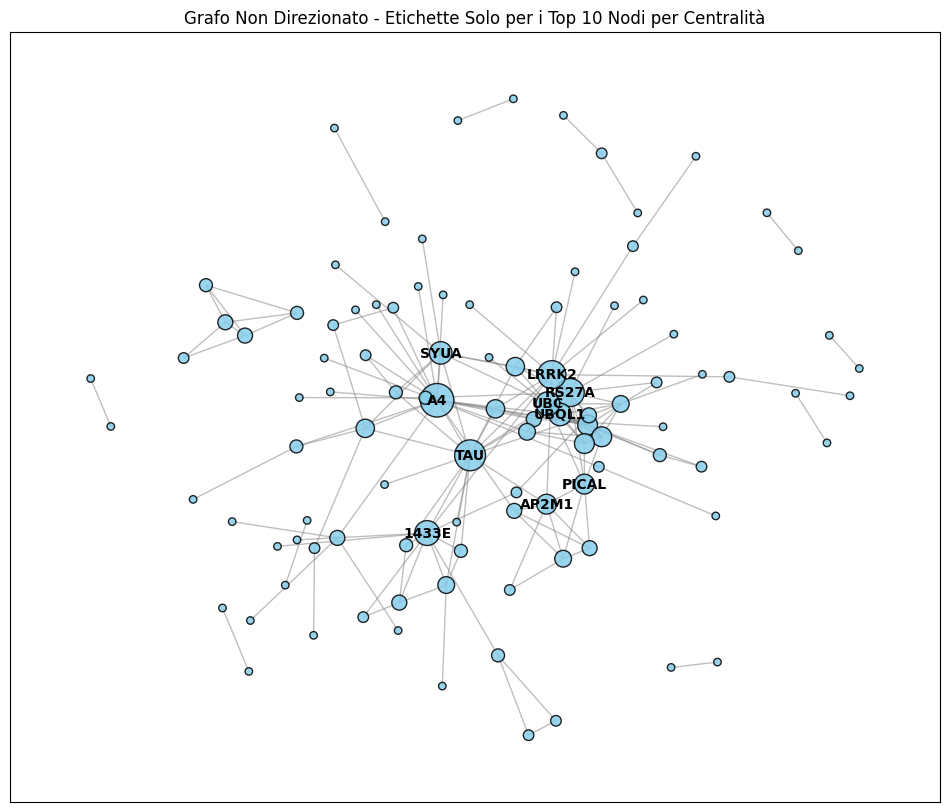

In [38]:
# Semplice visualizzazione del grafo dell'Alzheimer

import networkx as nx
import matplotlib.pyplot as plt


# Calcolare la centralità di grado
degree_centrality = nx.degree_centrality(AD)

# Trovare i top 10 nodi per centralità di grado
top_nodes = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
top_node_ids = {node for node, _ in top_nodes}  # Set con gli ID dei nodi top 10

label_column = 'Entry Name'

# Se il grafo ha un attributo "name", usiamolo per etichettare i nodi
if label_column in list(next(iter(AD.nodes(data=True))))[1]:  
    all_labels = {node: data[label_column].split('_')[0] for node, data in AD.nodes(data=True)}
else:
    all_labels = {node: node for node in AD.nodes()}  # Se non esiste, usa gli ID

# Creiamo un dizionario con le etichette solo per i top 10 nodi
labels = {node: all_labels[node] for node in top_node_ids}

# Normalizzare le dimensioni dei nodi (moltiplichiamo per 3000 per renderli più visibili)
node_sizes = [v * 3000 for v in degree_centrality.values()]

# Migliorare il layout aumentando la distanza tra i nodi
pos = nx.spring_layout(AD, seed=42, k=0.3)  # k regola la repulsione: valori più alti separano di più i nodi

# Disegnare il grafo
plt.figure(figsize=(12, 10))

nx.draw_networkx_nodes(AD, pos, node_size=node_sizes, alpha=0.85, node_color='skyblue', edgecolors='black')
nx.draw_networkx_edges(AD, pos, alpha=0.5, edge_color="gray", width=1)

# Disegnare SOLO le etichette dei top 10 nodi
nx.draw_networkx_labels(AD, pos, labels=labels, font_size=10, font_weight="bold")

plt.title("Grafo Non Direzionato - Etichette Solo per i Top 10 Nodi per Centralità")
plt.show()


{'A4', 'SYUB', 'KLK6', 'TAU', 'NU1M', 'UCHL1', 'RAB10', 'CDK5', 'LRRK2', 'SQSTM', 'SYUA', 'UB2L3'}


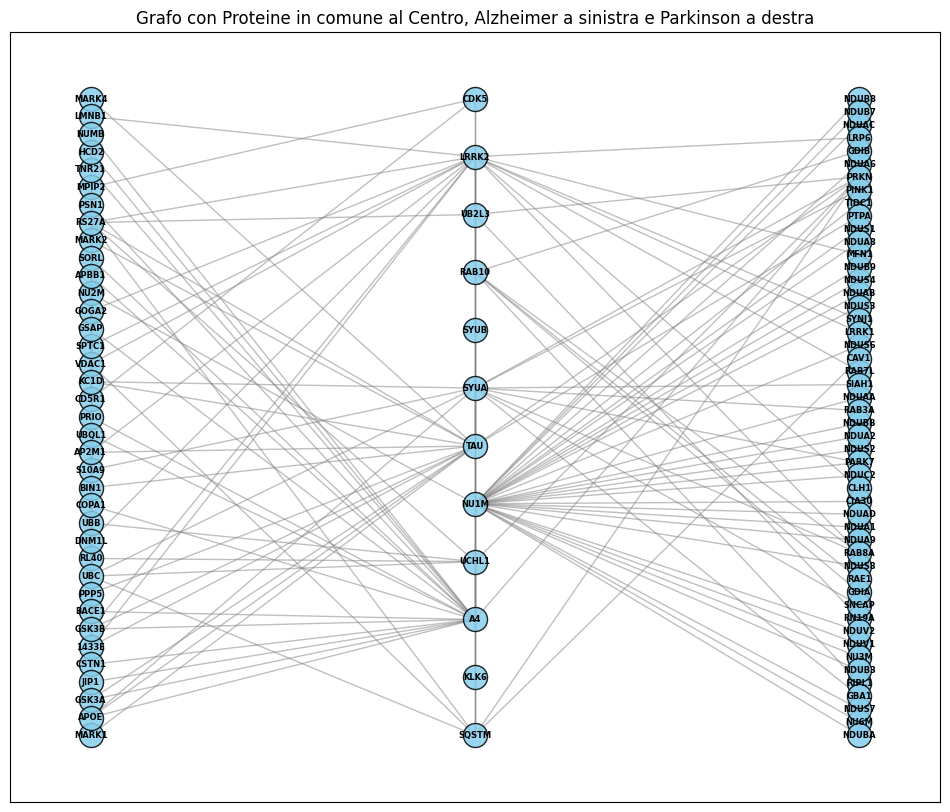

In [39]:
# Visualizzazione delle proteine della rete unita partizionando i nodi in base all'appartenenza ad una delle due malattie

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Estrarre i valori di "Partition" per ciascun nodo
partition_values = {node: int(data["Partition"]) for node, data in union_network.nodes(data=True) if "Partition" in data}

# Identificare i nodi di Partition = 3 (proteine in comune)
partition_3_nodes = {node for node, part in partition_values.items() if part == 3}
common_nodes = {union_network.nodes(data=True)[p]['Entry Name'].split('_')[0] for p in partition_3_nodes}
print(common_nodes)

# Identificare i nodi di Partition = 1 e 2 **solo se connessi a Partition = 3**
partition_1_nodes = {node for node, part in partition_values.items() if part == 1 and any(neigh in partition_3_nodes for neigh in union_network.neighbors(node))}
partition_2_nodes = {node for node, part in partition_values.items() if part == 2 and any(neigh in partition_3_nodes for neigh in union_network.neighbors(node))}

# Creare il sottografo contenente solo i nodi selezionati
filtered_nodes = partition_1_nodes | partition_2_nodes | partition_3_nodes
filtered_network = union_network.subgraph(filtered_nodes).copy()

# Aggiornare partition_values solo con i nodi del sottografo
partition_values = {node: partition_values[node] for node in filtered_network.nodes()}

# Creare i gruppi aggiornati
partition_groups = {1: list(partition_1_nodes), 2: list(partition_2_nodes), 3: list(partition_3_nodes)}

# Definire le posizioni per il layout personalizzato
pos = {}
x_positions = {1: 1, 3: 2, 2: 3}  # Definiamo le colonne

# Definire l'altezza massima e minima dell'area di visualizzazione
y_min, y_max = -5, 5  # Regolabile per più spazio verticale

# Distribuire uniformemente i nodi in ogni colonna
for partition, nodes in partition_groups.items():
    if len(nodes) > 1:
        y_positions = np.linspace(y_max, y_min, len(nodes))  # Distribuzione equidistante
    else:
        y_positions = [0]  # Se c'è solo un nodo, mettilo al centro
    
    for node, y in zip(nodes, y_positions):
        pos[node] = (x_positions[partition] * 3, y)  # Posizionare nel layout

# Se il grafo ha un attributo "Entry Name", usiamolo per etichettare i nodi
if "Entry Name" in list(next(iter(filtered_network.nodes(data=True))))[1]:  
    labels = {node: data["Entry Name"][:-6] for node, data in filtered_network.nodes(data=True)}
else:
    labels = {node: node for node in filtered_network.nodes()}  

# Calcolare la centralità di grado per ridimensionare i nodi
degree_centrality = nx.degree_centrality(filtered_network)
node_sizes = [degree_centrality[node] * 30000 for node in filtered_network.nodes()]

# Disegnare il grafo con layout a colonne basato su "partition"
plt.figure(figsize=(12, 10))

nx.draw_networkx_nodes(filtered_network, pos, alpha=0.85, node_color='skyblue', edgecolors='black')
nx.draw_networkx_edges(filtered_network, pos, alpha=0.5, edge_color="gray", width=1)
nx.draw_networkx_labels(filtered_network, pos, labels=labels, font_size=6, font_weight="bold")

# Aggiungere un titolo chiaro
plt.title("Grafo con Proteine in comune al Centro, Alzheimer a sinistra e Parkinson a destra")

plt.show()

# Passaggi preliminari per l'esportazione (Cytoscape)
attributes_to_remove = ['name', 'selected', 'AverageShortestPathLength', 'BetweennessCentrality', 'ClosenessCentrality', 'ClusteringCoefficient', 'Degree', 'Eccentricity', 'IsSingleNode', 'NeighborhoodConnectivity', 'NumberOfDirectedEdges', 'NumberOfUndirectedEdges', 'PartnerOfMultiEdgedNodePairs', 'Radiality', 'SelfLoops', 'Stress', 'TopologicalCoefficient', 'Matching.Attribute']
for node in filtered_network.nodes():
    for attr in attributes_to_remove:
        filtered_network.nodes[node].pop(attr, None)

attributes_to_remove = ['EdgeBetweenness']
for edge in filtered_network.edges():
    for attr in attributes_to_remove:
        filtered_network.edges[edge].pop(attr, None)

nx.write_graphml(filtered_network, 'linked_networks.graphml')


In [40]:
# Statistiche su distribuzione di archi e nodi tra reti complete e partizionate

num_nodes_full_network = len(union_network.nodes())
num_nodes_filtered_network = len(filtered_network.nodes())
num_edges_full_network = len(union_network.edges())
num_edges_filtered_network = len(filtered_network.edges())

nodes_overlap_percent = num_nodes_filtered_network / num_nodes_full_network * 100
edges_overlap_percent = num_edges_filtered_network / num_edges_full_network * 100

print(f'Percentuale di nodi della rete partizionata rispetto a quella intera: {nodes_overlap_percent:.2f}')
print(f'Percentuale di archi della rete partizionata rispetto a quella intera: {edges_overlap_percent:.2f}')

# Archi che collegano nodi di partizione 3 a partizione 1 e partizione 3 a partizione 3
left_links = [(u, v) for u, v in filtered_network.edges() if 
                     (u in partition_3_nodes and v in partition_1_nodes) or 
                     (u in partition_3_nodes and v in partition_3_nodes)]

# Archi che collegano nodi di partizione 3 a partizione 2 e partizione 3 a partizione 3
right_links = [(u, v) for u, v in filtered_network.edges() if 
                     (u in partition_3_nodes and v in partition_2_nodes) or 
                     (u in partition_3_nodes and v in partition_3_nodes)]

# Creazione dei sottografi
left_partition = nx.Graph()
left_partition.add_nodes_from(partition_3_nodes | partition_1_nodes)
left_partition.add_edges_from(left_links)

right_partition = nx.Graph()
right_partition.add_nodes_from(partition_3_nodes | partition_2_nodes)
right_partition.add_edges_from(right_links)


num_nodes_AD = len(AD.nodes())
num_edges_AD = len(AD.edges())
num_nodes_left_partition = len(left_partition.nodes())
num_edges_left_partition = len(left_partition.edges())

print(f'Percentuale di nodi della partizione AD rispetto alla rete di AD: {(num_nodes_left_partition / num_nodes_AD * 100):.2f}')
print(f'Percentuale di archi della partizione AD rispetto alla rete di AD: {(num_edges_left_partition / num_edges_AD * 100):.2f}')

num_nodes_PD = len(PD.nodes())
num_edges_PD = len(PD.edges())
num_nodes_right_partition = len(right_partition.nodes())
num_edges_right_partition = len(right_partition.edges())

print(f'Percentuale di nodi della partizione PD rispetto alla rete di PD: {(num_nodes_right_partition / num_nodes_PD * 100):.2f}')
print(f'Percentuale di archi della partizione PD rispetto alla rete di PD: {(num_edges_right_partition / num_edges_PD * 100):.2f}')

Percentuale di nodi della rete partizionata rispetto a quella intera: 55.31
Percentuale di archi della rete partizionata rispetto a quella intera: 79.73
Percentuale di nodi della partizione AD rispetto alla rete di AD: 47.12
Percentuale di archi della partizione AD rispetto alla rete di AD: 41.25
Percentuale di nodi della partizione PD rispetto alla rete di PD: 71.26
Percentuale di archi della partizione PD rispetto alla rete di PD: 5.00


In [41]:
# Creazione del meta-nodo per le proteine altamente connesse di PD

entry_names_cluster = {"9606.ENSP00000215565", "9606.ENSP00000233627", "9606.ENSP00000252102", "9606.ENSP00000252711", "9606.ENSP00000260361", "9606.ENSP00000263774", "9606.ENSP00000266544", "9606.ENSP00000268668", "9606.ENSP00000274137", "9606.ENSP00000276062", "9606.ENSP00000276689", "9606.ENSP00000281031", "9606.ENSP00000296597", "9606.ENSP00000296684", "9606.ENSP00000299166", "9606.ENSP00000315774", "9606.ENSP00000323076", "9606.ENSP00000327268", "9606.ENSP00000330737", "9606.ENSP00000351737", "9606.ENSP00000354665", "9606.ENSP00000355206", "9606.ENSP00000356972", "9606.ENSP00000358272", "9606.ENSP00000360492", "9606.ENSP00000362873", "9606.ENSP00000389160", "9606.ENSP00000392709", "9606.ENSP00000407336", "9606.ENSP00000418803", "9606.ENSP00000423673", "9606.ENSP00000482543", "9606.ENSP00000497587"}

# Creare una mappatura Entry Name -> Node ID
entry_name_to_node = {data["shared name"]: node for node, data in union_network.nodes(data=True)}

# Ottenere gli ID dei nodi corrispondenti agli Entry Name
cluster_nodes = {entry_name_to_node[name] for name in entry_names_cluster if name in entry_name_to_node}

meta_node = "Cluster_Meta"
network_with_metanode = union_network.copy()
network_with_metanode.add_node(meta_node, label="Meta Cluster")

# Creare connessioni tra il meta-nodo e tutti i nodi che erano connessi al cluster originale
for node in cluster_nodes:
    for neighbor in network_with_metanode.neighbors(node):
        if neighbor not in cluster_nodes:  # Evita connessioni interne al cluster
            network_with_metanode.add_edge(meta_node, neighbor)

# Rimuovere i nodi originali del cluster
network_with_metanode.remove_nodes_from(cluster_nodes)

print(f"Il cluster {entry_names_cluster} è stato condensato nel meta-nodo '{meta_node}'")


Il cluster {'9606.ENSP00000330737', '9606.ENSP00000296684', '9606.ENSP00000252711', '9606.ENSP00000252102', '9606.ENSP00000327268', '9606.ENSP00000215565', '9606.ENSP00000260361', '9606.ENSP00000392709', '9606.ENSP00000482543', '9606.ENSP00000362873', '9606.ENSP00000356972', '9606.ENSP00000268668', '9606.ENSP00000407336', '9606.ENSP00000315774', '9606.ENSP00000274137', '9606.ENSP00000360492', '9606.ENSP00000389160', '9606.ENSP00000418803', '9606.ENSP00000423673', '9606.ENSP00000296597', '9606.ENSP00000497587', '9606.ENSP00000358272', '9606.ENSP00000263774', '9606.ENSP00000351737', '9606.ENSP00000354665', '9606.ENSP00000233627', '9606.ENSP00000266544', '9606.ENSP00000299166', '9606.ENSP00000276689', '9606.ENSP00000281031', '9606.ENSP00000276062', '9606.ENSP00000323076', '9606.ENSP00000355206'} è stato condensato nel meta-nodo 'Cluster_Meta'


In [42]:
import pandas as pd

def get_entry_name(network, node):
    return network.nodes[node].get('Entry Name', node).split('_')[0]

def make_centrality_df(graph):
    degree_centrality = nx.degree_centrality(graph)
    betweenness_centrality = nx.betweenness_centrality(graph)
    closeness_centrality = nx.closeness_centrality(graph)
    eigenvector_centrality = nx.eigenvector_centrality(graph)
    pagerank = nx.pagerank(graph)

    df_centrality = pd.DataFrame({
        "Node": [get_entry_name(graph, n) for n in graph.nodes()],
        "Degree Centrality": [degree_centrality.get(n, 0) for n in graph.nodes()],
        "Betweenness Centrality": [betweenness_centrality.get(n, 0) for n in graph.nodes()],
        "Closeness Centrality": [closeness_centrality.get(n, 0) for n in graph.nodes()],
        "Eigenvector Centrality": [eigenvector_centrality.get(n, 0) for n in graph.nodes()],
        "PageRank": [pagerank.get(n, 0) for n in graph.nodes()]
    })

    df_centrality = df_centrality.sort_values(by="Degree Centrality", ascending=False)
    return df_centrality, df_centrality.columns.values[1:] # dataset e metriche usate

def plot_centrality_by_metric(df, metrics, title='Plot by centrality', save=False, top_n=10):
    _, axes = plt.subplots(1, 5, figsize=(18, 6))

    for i, metric in enumerate(metrics):
        df_sorted = df.sort_values(by=metric, ascending=False).head(top_n)  # Ordina e seleziona top 10
        colors = ['tomato' if str(node) in common_nodes else 'skyblue' for node in df_sorted["Node"]]
        axes[i].barh(df_sorted["Node"], df_sorted[metric], color=colors)
        axes[i].set_title(metric)
        axes[i].invert_yaxis()

    plt.tight_layout()
    plt.suptitle(title, y=1.05, fontsize=16)
    if save:
        plt.savefig('fig.png')
    plt.show()

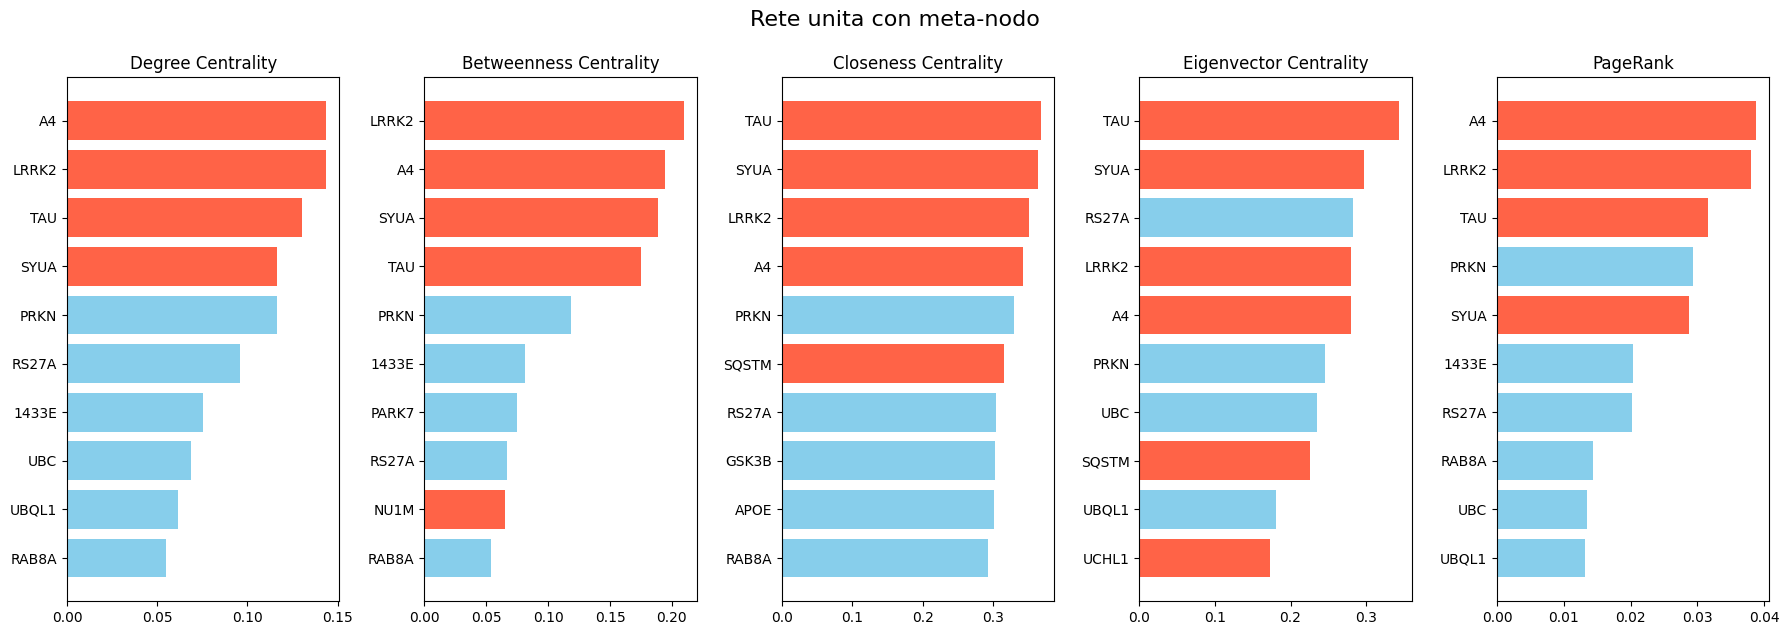

In [43]:
# [Rete unita] Plotting delle top-10 proteine per metrica di centralità

df_centrality, metrics = make_centrality_df(network_with_metanode)
plot_centrality_by_metric(df_centrality, metrics, title='Rete unita con meta-nodo', save=True, top_n=10)


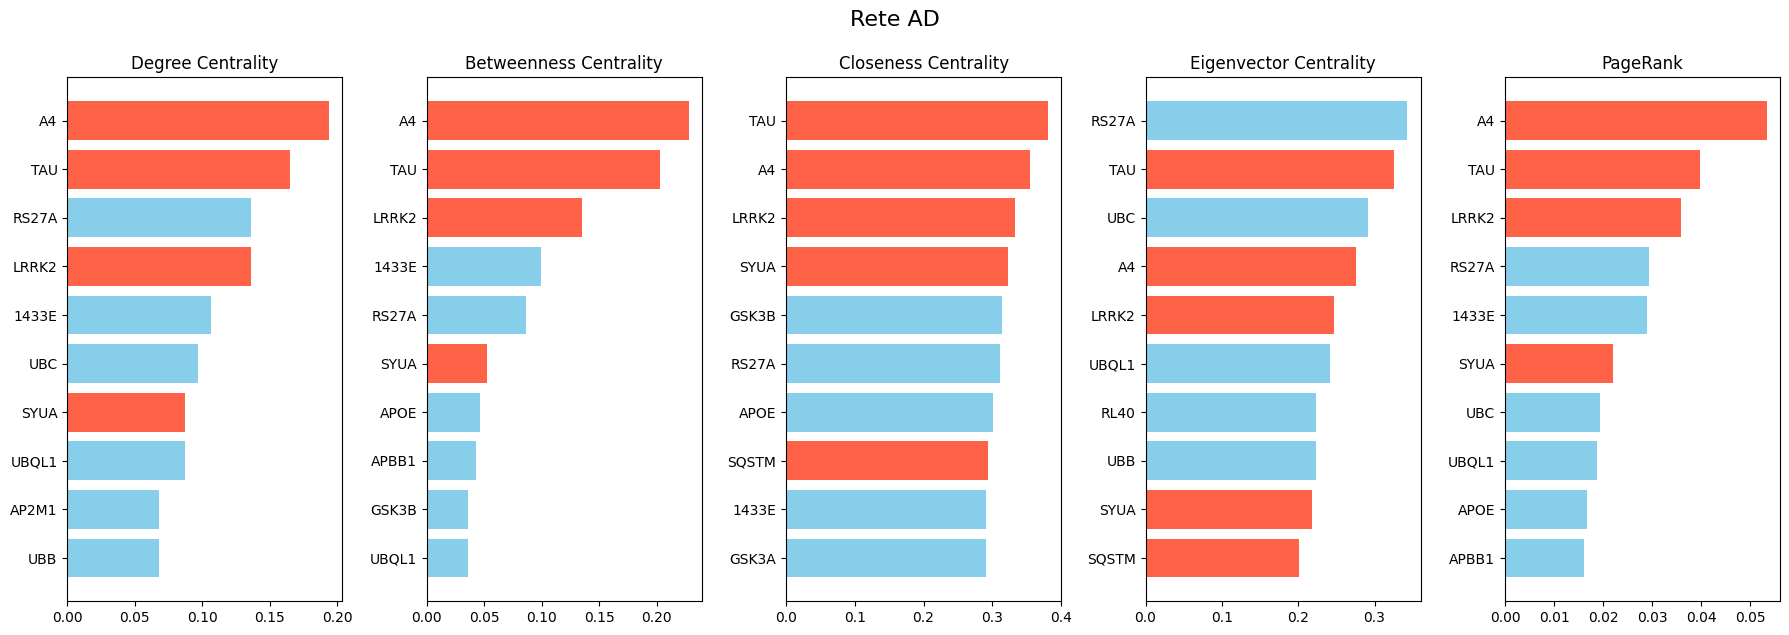

In [44]:
ad_centrality, metrics = make_centrality_df(AD)
plot_centrality_by_metric(ad_centrality, metrics, title='Rete AD')

Il cluster {'9606.ENSP00000330737', '9606.ENSP00000296684', '9606.ENSP00000252711', '9606.ENSP00000252102', '9606.ENSP00000327268', '9606.ENSP00000215565', '9606.ENSP00000260361', '9606.ENSP00000392709', '9606.ENSP00000482543', '9606.ENSP00000362873', '9606.ENSP00000356972', '9606.ENSP00000268668', '9606.ENSP00000407336', '9606.ENSP00000315774', '9606.ENSP00000274137', '9606.ENSP00000360492', '9606.ENSP00000389160', '9606.ENSP00000418803', '9606.ENSP00000423673', '9606.ENSP00000296597', '9606.ENSP00000497587', '9606.ENSP00000358272', '9606.ENSP00000263774', '9606.ENSP00000351737', '9606.ENSP00000354665', '9606.ENSP00000233627', '9606.ENSP00000266544', '9606.ENSP00000299166', '9606.ENSP00000276689', '9606.ENSP00000281031', '9606.ENSP00000276062', '9606.ENSP00000323076', '9606.ENSP00000355206'} è stato condensato nel meta-nodo 'Cluster_Meta'


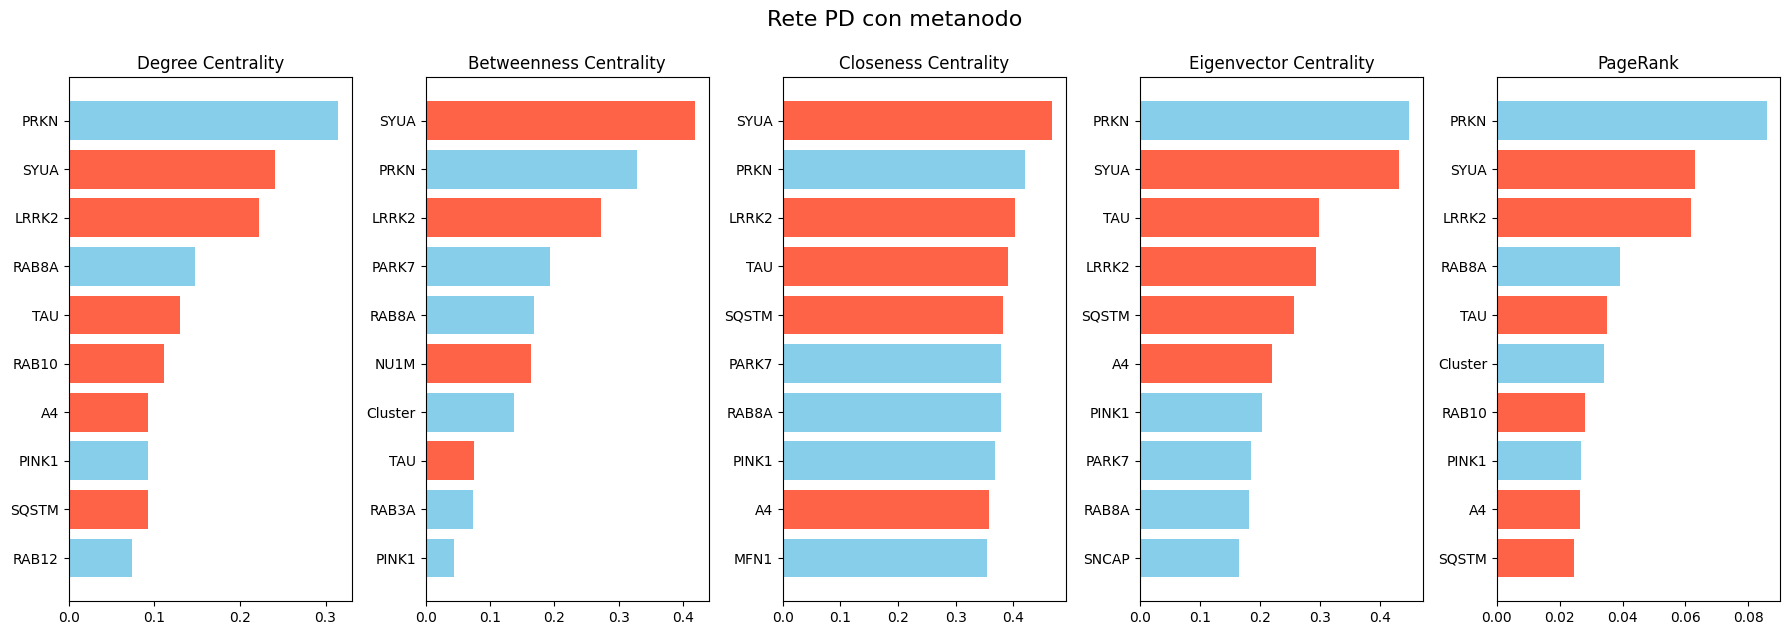

In [45]:
# Creazione del meta-nodo per le proteine altamente connesse di PD
entry_names_cluster = {"9606.ENSP00000215565", "9606.ENSP00000233627", "9606.ENSP00000252102", "9606.ENSP00000252711", "9606.ENSP00000260361", "9606.ENSP00000263774", "9606.ENSP00000266544", "9606.ENSP00000268668", "9606.ENSP00000274137", "9606.ENSP00000276062", "9606.ENSP00000276689", "9606.ENSP00000281031", "9606.ENSP00000296597", "9606.ENSP00000296684", "9606.ENSP00000299166", "9606.ENSP00000315774", "9606.ENSP00000323076", "9606.ENSP00000327268", "9606.ENSP00000330737", "9606.ENSP00000351737", "9606.ENSP00000354665", "9606.ENSP00000355206", "9606.ENSP00000356972", "9606.ENSP00000358272", "9606.ENSP00000360492", "9606.ENSP00000362873", "9606.ENSP00000389160", "9606.ENSP00000392709", "9606.ENSP00000407336", "9606.ENSP00000418803", "9606.ENSP00000423673", "9606.ENSP00000482543", "9606.ENSP00000497587"}

# Creare una mappatura Entry Name -> Node ID
entry_name_to_node = {data["shared name"]: node for node, data in PD.nodes(data=True)}

# Ottenere gli ID dei nodi corrispondenti agli Entry Name
cluster_nodes = {entry_name_to_node[name] for name in entry_names_cluster if name in entry_name_to_node}

meta_node = "Cluster_Meta"
pd_network_with_metanode = PD.copy()
pd_network_with_metanode.add_node(meta_node, label="Meta Cluster")

# Creare connessioni tra il meta-nodo e tutti i nodi che erano connessi al cluster originale
for node in cluster_nodes:
    for neighbor in pd_network_with_metanode.neighbors(node):
        if neighbor not in cluster_nodes:  # Evita connessioni interne al cluster
            pd_network_with_metanode.add_edge(meta_node, neighbor)

# Rimuovere i nodi originali del cluster
pd_network_with_metanode.remove_nodes_from(cluster_nodes)

print(f"Il cluster {entry_names_cluster} è stato condensato nel meta-nodo '{meta_node}'")

pd_centrality, metrics = make_centrality_df(pd_network_with_metanode)
plot_centrality_by_metric(pd_centrality, metrics, title='Rete PD con metanodo')

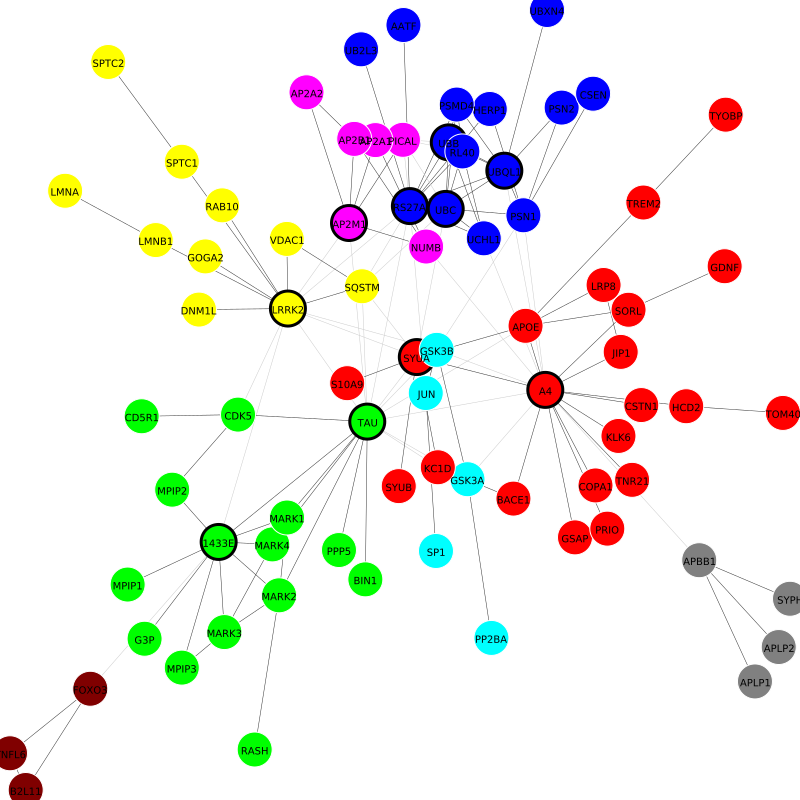

In [75]:
import igraph as ig
import leidenalg

# Componente connessa più popolosa di AD
connected_components = list(nx.connected_components(AD))
largest_component = max(connected_components, key=len)
largest_subgraph_ad = AD.subgraph(largest_component).copy()

# Lista dei nodi da evidenziare (sostituisci con i tuoi nodi)
highlighted_nodes = ad_centrality.sort_values(by='Degree Centrality', ascending=False).head(10)['Node'].to_list()

# Creare un mapping tra ID e "Entry Name" (eliminando gli ultimi 6 caratteri)
entry_name_mapping = {node: data["Entry Name"][:-6] for node, data in largest_subgraph_ad.nodes(data=True) if "Entry Name" in data}

# Convertire il grafo NetworkX in iGraph mantenendo i nomi originali
g = ig.Graph.TupleList(largest_subgraph_ad.edges(), directed=False)
g.vs["label"] = [entry_name_mapping.get(node, str(node)) for node in g.vs["name"]]  # Usa "Entry Name" se presente

# Applicare Leiden per trovare le comunità
leiden_communities = leidenalg.find_partition(g, leidenalg.ModularityVertexPartition)

# Impostare lo stile dei nodi
layout = g.layout('fr') # Force-Directed Layout
layout.scale(10000)
visual_style = {
    "vertex_size": 35,
    "vertex_label": g.vs["label"],  # Mostra i nomi delle proteine invece degli ID
    "vertex_label_size": 10,
    "vertex_frame_width": [3 if label in highlighted_nodes else 1 for label in g.vs["label"]],  # Bordi più spessi per i nodi evidenziati
    "vertex_frame_color": ["black" if label in highlighted_nodes else "white" for label in g.vs["label"]],  # Cambia il colore del bordo
    "edge_width": 0.5,
    "bbox": (800, 800),  # Dimensione della figura
    "margin": 10,
    "layout": layout  
}

# Disegnare il grafo con nodi cerchiati
ig.plot(leiden_communities, **visual_style)


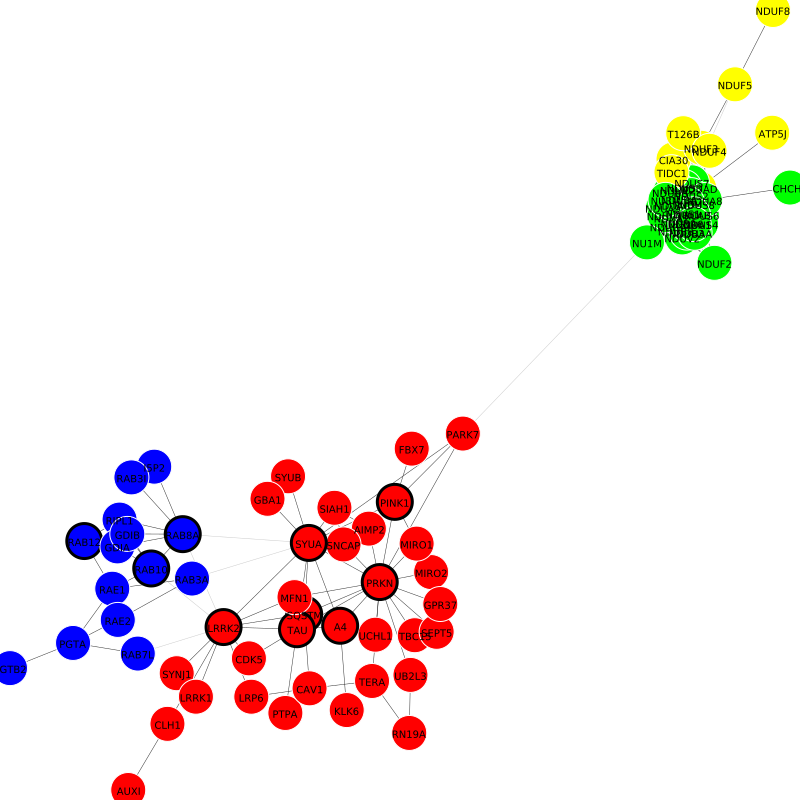

In [90]:
import igraph as ig
import leidenalg

# Componente connessa più popolosa di PD
connected_components = list(nx.connected_components(PD))
largest_component = max(connected_components, key=len)
largest_subgraph_pd = PD.subgraph(largest_component).copy()

# Lista dei nodi da evidenziare (sostituisci con i tuoi nodi)
highlighted_nodes = pd_centrality.sort_values(by='Degree Centrality', ascending=False).head(10)['Node'].to_list()

# Creare un mapping tra ID e "Entry Name" (eliminando gli ultimi 6 caratteri)
entry_name_mapping = {node: data["Entry Name"][:-6] for node, data in largest_subgraph_pd.nodes(data=True) if "Entry Name" in data}

# Convertire il grafo NetworkX in iGraph mantenendo i nomi originali
g = ig.Graph.TupleList(largest_subgraph_pd.edges(), directed=False)
g.vs["label"] = [entry_name_mapping.get(node, str(node)) for node in g.vs["name"]]  # Usa "Entry Name" se presente

# Applicare Leiden per trovare le comunità
leiden_communities = leidenalg.find_partition(g, leidenalg.ModularityVertexPartition)

# Impostare lo stile dei nodi
layout = g.layout("fr")
layout.scale(1000)
visual_style = {
    "vertex_size": 35,
    "vertex_label": g.vs["label"],  # Mostra i nomi delle proteine invece degli ID
    "vertex_label_size": 10,
    "vertex_frame_width": [3 if label in highlighted_nodes else 1 for label in g.vs["label"]],  # Bordi più spessi per i nodi evidenziati
    "vertex_frame_color": ["black" if label in highlighted_nodes else "white" for label in g.vs["label"]],  # Cambia il colore del bordo
    "edge_width": 0.5,
    "bbox": (800, 800),  # Dimensione della figura
    "margin": 10,
    "layout": layout  
}

# Disegnare il grafo con nodi cerchiati
ig.plot(leiden_communities, **visual_style)
